# Calinski-Harabasz index

scikit-learn and back-of-envelop calculations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics, datasets, cluster

In [2]:
def calcch(X, y):
    n_clusters = len(np.unique(y))
    n_samples = X.shape[0]
    overall_mean = X.mean(axis=0)

    centroid = np.zeros((n_clusters, X.shape[1]))
    ssb, ssw = 0, 0
    for n_cluster in range(n_clusters):
        i = np.where(y==n_cluster)[0]
        ni = len(i)
        centroid[n_cluster, :] = X[i].mean(axis=0)
        ssb += ni * np.linalg.norm(centroid[n_cluster] - overall_mean)**2
        for xx in X[i, :]:
            ssw += np.linalg.norm(centroid[n_cluster] - xx)**2
    CH = ssb / ssw * (n_samples - n_clusters) / (n_clusters - 1)
    return CH

## Example #1

In [3]:
X = [[1, 2],
     [3, 4],
     [5, 6],
     [7, 8]]
y = [0, 1, 0, 1]
X = np.array(X); y = np.array(y)

print('CH score calculated using scikit-learn:', metrics.calinski_harabasz_score(X, y))
print('CH score calculated semi-automatically:', calcch(X, y))

CH score calculated using scikit-learn: 0.5
CH score calculated semi-automatically: 0.5


Manual back-of-envelop calculation

n_clusters = 2

n_samples = 4

overall_mean = [4, 5]

Cluster #0: X = [[1, 2], [5, 6]], y = 0, centroid = [3, 4]

            ssb = 2 * (Euclidean between [3, 4] and [4, 5])^2 

                = 4

            ssw = (Euclidean between [1, 2] and [3, 4])^2 +

                  (Euclidean between [5, 6] and [3, 4])^2

                = 16
                
Cluster #1: X = [[3, 4], [7, 8]], y = 1, centroid = [5, 6]  

            ssb = 2 * (Euclidean between [5, 6] and [4, 5])^2

                = 4

            ssw = (Euclidean between [3, 4] and [5, 6])^2 +  

                  (Euclidean between [7, 8] and [5, 6])^2  

                = 16
             
ssb = 4 + 4 = 8

ssw = 16 + 16 = 32

ch = 8 / 32 * (4 - 2) / (2 - 1) = 0.5

## Example #2

In [4]:
X = [[-1, -2],
     [-3,  4],
     [ 5, -6],
     [ 7,  8]]
y = [0, 1, 1, 1]
X = np.array(X); y = np.array(y)

print('CH score calculated using scikit-learn:', metrics.calinski_harabasz_score(X, y))
print('CH score calculated semi-automatically:', calcch(X, y))

CH score calculated using scikit-learn: 0.3
CH score calculated semi-automatically: 0.3


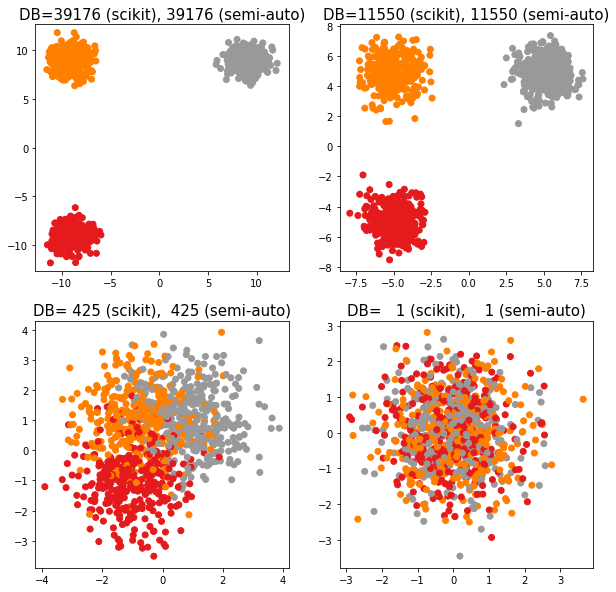

In [5]:
n_samples = 1000
centerss = [[[-9, -9], [-9, 9], [9, 9]],
            [[-5, -5], [-5, 5], [5, 5]],
            [[-1, -1], [-1, 1], [1, 1]],
            [[ 0,  0], [ 0, 0], [0, 0]]]
plt.figure(figsize=(10, 10)); plt.set_cmap('Set1')
for n, centers in enumerate(centerss):         
    plt.subplot(2, 2, n+1)
    X, y = datasets.make_blobs(n_samples=n_samples, centers=centers)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.axis('equal')
    plt.title('DB={:4.0f} (scikit), {:4.0f} (semi-auto)'.format(
        metrics.calinski_harabasz_score(X, y), calcch(X, y)), size=15)

## Example #3

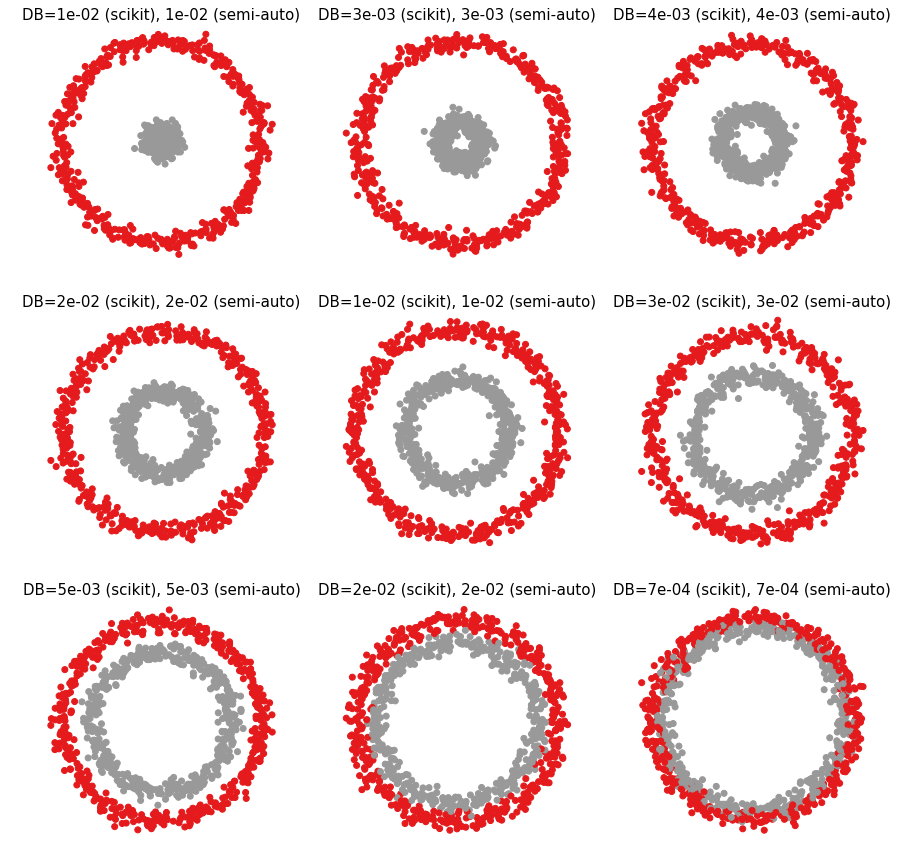

In [6]:
np.random.seed(77)
n_samples = 1000
plt.figure(figsize=(15, 15)); plt.set_cmap('Set1')
for n, factor in enumerate(np.arange(.1, 1, .1)):
    X, y = datasets.make_circles(n_samples=n_samples, factor=factor, noise=.05)
    plt.subplot(3, 3, n+1)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.axis('equal'); plt.axis('off')
    plt.title('DB={:4.0e} (scikit), {:4.0e} (semi-auto)'.format(
        metrics.calinski_harabasz_score(X, y), calcch(X, y)), size=15)

### Bibliography
https://www.mathworks.com/help/stats/clustering.evaluation.calinskiharabaszevaluation-class.html